# Random FDLU noising

Created: 23-06-2026

Objectives:
* Build off [previous notebook](zxz_y_tensor_network_factorization_sweep.ipynb), but now implement Kyle's suggestion to apply random FDLU circuits to states and check the results.

# Imports

In [1]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
from tqdm import tqdm

In [4]:
from functools import reduce

In [5]:
import quimb.tensor as qtn
import quimb as qu

In [6]:
from scipy.stats import ortho_group

In [81]:
from collections import Counter

In [90]:
import pandas as pd

# Definitions
## Groundstates

In [7]:
num_sites = 16

In [8]:
basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)

In [9]:
# Use periodic boundary conditions.
def get_hamiltoniain(t, L=num_sites):
    static = [
        ["zxz", [[-t, i, (i+1)%L, (i+2)%L] for i in range(L)]],
        ["y", [[-(1-t), i] for i in range(L)]],
    ]
    dynamic = []

    basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)
    out = hamiltonian(
        static,
        [],
        basis=basis,
        dtype=np.complex128,
        check_symm=False,
        check_herm=False
    )

    return out

In [10]:
parameters = np.linspace(0, 1, 11)

In [11]:
hamiltonians = [
    get_hamiltoniain(t, num_sites)
    for t in parameters
]

In [12]:
energies = list()
groundstates = list()

for h in tqdm(hamiltonians):
    e, psi = h.eigsh(k=1, which='SA')

    energies.append(e)
    groundstates.append(psi)

100%|█████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:06<00:00,  1.72it/s]


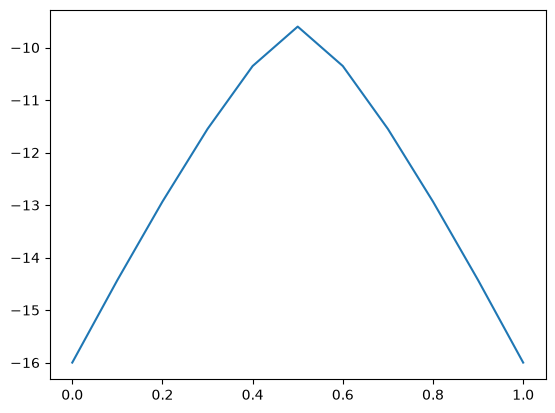

In [13]:
plt.plot(parameters, energies)

## Symmetries
Symmetry of the system is $XK$, where $K$ is complex conjugation.

In [14]:
np_X = np.array([
    [0,1],
    [1,0]
])

np_XX = np.kron(np_X, np_X)

In [15]:
qu_XX = qtn.Tensor(
    np_XX,
    inds=['k', 'b']
)

## Defect operators

In [16]:
symmetry_sites = list(range(4, 12))

num_symmetry_sites = len(symmetry_sites)

In [17]:
basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)

In [18]:
horiztonal_bond_dimension = 16
vertical_bond_dimension = 4

In [19]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [20]:
def get_rho_A(A):
    A_bottom = A.conj().reindex({'kl': 'bl', 'kr': 'br'})
    return A & A_bottom

In [21]:
def rho_A_trace(rho_A):
    out = (
        rho_A
        .reindex({'bl': 'kl', 'br': 'kr'})
        .contract()
    )
    return out

In [22]:
def normalize_A(A):
    rho_A = get_rho_A(A)
    trace = rho_A_trace(rho_A)
    return A.multiply(trace**(-0.5))

In [23]:
transpose_reindex_dict = {
    'bl': 'kl',
    'br': 'kr',
    'kl': 'bl',
    'kr': 'br'
}

In [24]:
def rho_A_purity(rho_A):
    tn = (
        (rho_A.reindex(transpose_reindex_dict))
        & rho_A
    )

    out = tn.contract()

    return out

In [25]:
def rho_A_rho_overlap(rho, rho_A):
    tn = (
        (rho_A.reindex(transpose_reindex_dict))
        & rho
    )

    out = tn.contract()

    return out

In [26]:
def loss_func(A, rho, rho_purity):
    rho_A = get_rho_A(A)

    out = np.real(
        rho_purity
        + rho_A_purity(rho_A)
        -2*rho_A_rho_overlap(rho, rho_A)
    )

    return out

In [27]:
def get_tensor_network_factorization(psi):
    rho = basis.partial_trace(
        psi,
        sub_sys_A=symmetry_sites,
        return_rdm="A",
        enforce_pure=True
    )

    rho_purity = np.real(np.trace(rho @ rho))

    # Hardcode warning
    rho_reshaped = rho.reshape((16, 16, 16, 16,))
    
    qt_rho = qtn.Tensor(
        data=rho_reshaped,
        inds=('kl', 'kr', 'bl', 'br')
    )

    A_left = qtn.Tensor(
        data=random_uniform_complex(
            (vertical_bond_dimension, 2**4, horiztonal_bond_dimension)
        ),
        inds=('vLV', 'kl', 'vH')
    )
    
    A_right = qtn.Tensor(
        data=random_uniform_complex(
            (horiztonal_bond_dimension, 2**4, vertical_bond_dimension)
        ),
        inds=('vH', 'kr', 'vRV')
    )

    A = qtn.TensorNetwork([A_left, A_right])

    tnopt = qtn.TNOptimizer(
        A,  # the tensor network we want to optimize
        loss_func,  # the function we want to minimize
        norm_fn=normalize_A,
        loss_constants={"rho": qt_rho, "rho_purity": rho_purity},
        autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
        optimizer="L-BFGS-B",  # the optimization algorithm
        progbar=False
    )

    A_opt = tnopt.optimize_basinhopping(n=100,  nhop=5)

    return A_opt, tnopt.losses, tnopt.loss_best

In [28]:
def schmidt_decompose_tensor_factorization(A_opt):
    # Left side
    A_l_opt = A_opt.tensors[0]

    tn_l = (
        A_l_opt
        &
        A_l_opt.conj().reindex({'kl': 'bl', 'vH': 'vBH'})
    )
    tn_l = tn_l.contract()

    left_rho_decomp = qtn.tensor_core.tensor_split(
        tn_l,
        left_inds=['kl', 'vH'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vLV'
    )

    diff_l = (
        left_rho_decomp.contract(output_inds=tn_l.inds)
        - tn_l
    )

    left_diff = (diff_l & diff_l.conj()).contract()

    # Right side
    A_r_opt = A_opt.tensors[1]

    tn_r = (
        A_r_opt
        &
        A_r_opt.conj().reindex({'kr': 'br', 'vH': 'vBH'})
    )
    tn_r = tn_r.contract()

    right_rho_decomp = qtn.tensor_core.tensor_split(
        tn_r,
        left_inds=['kr', 'vH'],
        method='svd',
        #cutoff=1e-3,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vRV'
    )

    diff_r = (
        right_rho_decomp.contract(output_inds=tn_r.inds)
        - tn_r
    )

    right_diff = (diff_r & diff_r.conj()).contract()

    out = (
        left_rho_decomp,
        right_rho_decomp,
        left_diff,
        right_diff
    )

    return out

In [29]:
def get_defect_operators(edm, num_iters=20):
    # Assuming edm has indices [kl1, kr2, bl1, br2] each with size 4 (s sites)
    scores = list()

    left_defect_op = qtn.tensor_builder.rand_tensor(
        (4, 4),
        inds=['kl1', 'bl1'],
        dtype='complex64'
    )

    right_defect_op = qtn.tensor_builder.rand_tensor(
        (4, 4),
        inds=['kr2', 'br2'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (
            (
                edm
                & left_defect_op.reindex({'kl1': 'bl1', 'bl1':'kl1'})
            )
            .contract()
        )
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        right_defect_op = qtn.Tensor(sol, inds = ['kr2', 'br2'])
        
        left_edm = (
            (
                edm
                & right_defect_op.reindex({'kr2': 'br2', 'br2':'kr2'})
            )
            .contract()    
        )
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        left_defect_op = qtn.Tensor(sol, inds = ['kl1', 'bl1'])

    return (left_defect_op, right_defect_op), scores

In [30]:
def get_defect_ops_and_indices_from_density_matrix(qt_rho):
    rho_purification = qtn.tensor_core.tensor_split(
        qt_rho,
        left_inds=['kl', 'kr'],
        method='eigh',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    purification_diff = rho_purification.contract(output_inds=qt_rho.inds) - qt_rho
    purification_diff_score = (purification_diff & purification_diff.conj()).contract()

    bra_conjugate_rho = (
        rho_purification.tensors[0]
        & rho_purification.tensors[1]
        & (rho_purification.tensors[2].conj())
    )

    (
        bra_conjugate_rho
        .tensors[0]
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'kr': ['kr1', 'kr2']},
            shape_map={'kl': (4, 4), 'kr': (4, 4)}
        )
    )
    
    (
        bra_conjugate_rho
        .tensors[2]
        .unfuse_(
            unfuse_map={'bl': ['bl1', 'bl2'], 'br': ['br1', 'br2']},
            shape_map={'bl': (4, 4), 'br': (4, 4)}
        )
    )

    # Effective density matrix
    edm = (
        bra_conjugate_rho.reindex(
            {'bl1': 'bbl1', 'bl2': 'bl2', 'br1': 'br1', 'br2': 'bbr2'}
        )
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
    )

    # Ordering of indices important here.
    edm = edm.contract(output_inds=['kl1', 'kr2', 'bl1', 'br2'])

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_defect_l = (
        qt_rho
        .reindex({'kr': 'br'})
        .contract()
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'bl': ['bl1', 'bl2']},
            shape_map={'kl': (4, 4), 'bl': (4,4)}
        )
        .reindex({'kl2': 'bl2'})
        .contract()
    )

    left_defect_op_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_defect_r = (
        qt_rho
        .reindex({'kl': 'bl'})
        .contract()
        .unfuse_(
            unfuse_map={'kr': ['kr1', 'kr2'], 'br': ['br1', 'br2']},
            shape_map={'kr': (4, 4), 'br': (4,4)}
        )
        .reindex({'kr1': 'br1'})
        .contract()
    )

    right_defect_op_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps,
        purification_diff_score
    )

    return out

In [31]:
def get_defect_ops_and_indices_from_factorized_density_matrix(qt_rho,
    left_rho_decomp, right_rho_decomp):

    bra_conjugate_left_rho_decomp = (
        left_rho_decomp.tensors[0]
        & left_rho_decomp.tensors[1]
        & (left_rho_decomp.tensors[2].conj())
    )
    
    bra_conjugate_right_rho_decomp = (
        right_rho_decomp.tensors[0]
        & right_rho_decomp.tensors[1]
        & (right_rho_decomp.tensors[2].conj())
    )

    (
        bra_conjugate_left_rho_decomp
        .tensors[0]
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2']},
            shape_map={'kl': (4, 4)}
        )
    )
    
    (
        bra_conjugate_left_rho_decomp
        .tensors[2]
        .unfuse_(
            unfuse_map={'bl': ['bl1', 'bl2']},
            shape_map={'bl': (4, 4)}
        )
    )
    
    (
        bra_conjugate_right_rho_decomp
        .tensors[0]
        .unfuse_(
            unfuse_map={'kr': ['kr1', 'kr2']},
            shape_map={'kr': (4, 4)}
        )
    )
    
    (
        bra_conjugate_right_rho_decomp
        .tensors[2]
        .unfuse_(
            unfuse_map={'br': ['br1', 'br2']},
            shape_map={'br': (4, 4)}
        )
    )

    # Effective density matrix
    edm = (
        bra_conjugate_left_rho_decomp.reindex({'bl1': 'bbl1', 'bl2': 'bl2'})
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
        & bra_conjugate_right_rho_decomp.reindex({'br1': 'br1', 'br2': 'bbr2'})
    )

    edm = edm.contract(output_inds=['kl1', 'kr2', 'bl1', 'br2'])

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_defect_l = (
        qt_rho
        .reindex({'kr': 'br'})
        .contract()
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'bl': ['bl1', 'bl2']},
            shape_map={'kl': (4, 4), 'bl': (4,4)}
        )
        .reindex({'kl2': 'bl2'})
        .contract()
    )

    left_defect_op_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_defect_r = (
        qt_rho
        .reindex({'kl': 'bl'})
        .contract()
        .unfuse_(
            unfuse_map={'kr': ['kr1', 'kr2'], 'br': ['br1', 'br2']},
            shape_map={'kr': (4, 4), 'br': (4,4)}
        )
        .reindex({'kr1': 'br1'})
        .contract()
    )

    right_defect_op_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl1': 'bl1', 'bl1': 'kl1'})
        & right_defect_operator.reindex({'kr2': 'br2', 'br2': 'kr2'})
    )

    overlap = np.abs(overlap.contract())

    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps
    )

    return out

In [32]:
def get_defect_ops_and_indices_from_restricted_state(psi_restricted):
    psi_0 = psi_restricted

    # Effective density matrix
    edm = (
        psi_0
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
        & psi_0.reindex({
            'kl1': 'bbl1', 'kl2': 'bl2', 'kr1': 'br1', 'kr2': 'bbr2'
        })
    )

    edm = edm.contract()

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_0 = (
        psi_0
        & psi_0.conj().reindex({'kl1': 'bl1', 'kr2': 'br2'})
    )
    
    rho_0_l = rho_0.reindex({'br2': 'kr2'}).contract()

    left_defect_op_invariant = (
        rho_0_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_0_r = rho_0.reindex({'bl1': 'kl1'}).contract()

    right_defect_op_invariant = (
        rho_0_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl1': 'bl1', 'bl1': 'kl1'})
        & right_defect_operator.reindex({'kr2': 'br2', 'br2': 'kr2'})
    )

    overlap = np.abs(overlap.contract())
    
    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlap
    )

    return out

In [33]:
def get_defect_ops_and_indices_from_restricted_purification_state(psi_restricted):
    psi_0 = psi_restricted

    # Effective density matrix
    edm = (
        psi_0
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
        & psi_0.reindex({
            'kl1': 'bbl1', 'kl2': 'bl2', 'kr1': 'br1', 'kr2': 'bbr2'
        })
    )

    edm = edm.contract()

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_0 = (
        psi_0
        & psi_0.conj().reindex({'kl1': 'bl1', 'kr2': 'br2'})
    )

    rho_0_l = rho_0.reindex({'br2': 'kr2'}).contract()

    left_defect_op_invariant = (
        rho_0_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_0_r = rho_0.reindex({'bl1': 'kl1'}).contract()

    right_defect_op_invariant = (
        rho_0_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    
    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps
    )

    return out

In [34]:
def get_restricted_psis(left_rho_decomp, right_rho_decomp, cutoff_factor=0.8):
    out = list()

    left_schmidt_vals = left_rho_decomp.tensors[1].data
    right_schmidt_vals = right_rho_decomp.tensors[1].data

    
    
    for i, sl in enumerate(left_schmidt_vals):
        if sl >= cutoff_factor*max(left_schmidt_vals):
            left_psi = left_rho_decomp.tensors[0].isel({'vLV': i})
            for j, sr in enumerate(right_schmidt_vals):
                if sr >= cutoff_factor*max(right_schmidt_vals):
                    right_psi = right_rho_decomp.tensors[0].isel({'vRV': j})

                    psi = left_psi & right_psi
                    psi_norm = (psi & psi.conj()).contract()

                    (
                        psi
                        .multiply(
                            psi_norm**(-0.5),
                            inplace=True,
                            spread_over=2
                        )
                    )

                    (
                        psi
                        .tensors[0]
                        .unfuse_(
                            unfuse_map={'kl': ['kl1', 'kl2']},
                            shape_map={'kl': (4, 4)}
                        )
                    )

                    (
                        psi
                        .tensors[1]
                        .unfuse_(
                            unfuse_map={'kr': ['kr1', 'kr2']},
                            shape_map={'kr': (4, 4)}
                        )
                    )

                    out.append([psi, sl, sr])

    return out

In [35]:
def get_restricted_psis_from_purification(qt_rho, cutoff_factor=0.65):
    out = list()

    rho_purification = qtn.tensor_core.tensor_split(
        qt_rho,
        left_inds=['kl', 'kr'],
        method='eigh',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    purification_diff = rho_purification.contract(output_inds=qt_rho.inds) - qt_rho
    purification_diff_score = (purification_diff & purification_diff.conj()).contract()

    schmidt_vals = rho_purification.tensors[1].data
    
    for i, schmidt_val in enumerate(schmidt_vals):
        if schmidt_val >= cutoff_factor*max(schmidt_vals):
            psi = rho_purification.tensors[0].isel({'vV': i})
            psi_norm = (psi & psi.conj()).contract()

            psi = psi_norm**(-0.5)*psi

            (
                psi
                .unfuse_(
                    unfuse_map={'kl': ['kl1', 'kl2'], 'kr': ['kr1', 'kr2']},
                    shape_map={'kl': (4, 4), 'kr': (4, 4)}
                )
            )

            out.append([psi, schmidt_val])

    return (out, purification_diff_score)

In [36]:
def get_left_right_defect_regions_schmidt_vals(qt_rho):
    unfuse_map = {
        'kl': ['kl1', 'kl2'],
        'kr': ['kr1', 'kr2'],
        'bl': ['bl1', 'bl2'],
        'br': ['br1', 'br2']
    }
    shape_map = {k: (4,4) for k in unfuse_map.keys()}

    rho = (
        qt_rho
        .unfuse(unfuse_map=unfuse_map, shape_map=shape_map)
    )

    rho = rho.reindex({'kl2': 'bl2', 'kr1': 'br1'})
    rho = rho.contract()

    rho_left_right_split = qtn.tensor_core.tensor_split(
        rho,
        left_inds=['kl1', 'bl1'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    rho_left_right_schmidt_vals = rho_left_right_split.tensors[1].data

    return rho_left_right_schmidt_vals

In [37]:
def extract_time_reversal_information(psi):
    rho = basis.partial_trace(
        psi,
        sub_sys_A=symmetry_sites,
        return_rdm="A",
        enforce_pure=True
    )
    
    rho_purity = np.real(np.trace(rho @ rho))
    
    # Hardcode warning
    rho_reshaped = rho.reshape((16, 16, 16, 16,))
    
    qt_rho = qtn.Tensor(
        data=rho_reshaped,
        inds=('kl', 'kr', 'bl', 'br')
    )

    qt_rho_left_right_schmidt_vals = (
        get_left_right_defect_regions_schmidt_vals(qt_rho)
    )

    rho_out = get_defect_ops_and_indices_from_density_matrix(qt_rho)

    pair = get_restricted_psis_from_purification(qt_rho)
    purification_restricted_psi_pairs, purification_diff_score = pair

    purification_restricted_psi_output = list()
    for psi_0, sv in purification_restricted_psi_pairs:
        purification_restricted_psi_output.append(
            [sv, *get_defect_ops_and_indices_from_restricted_purification_state(psi_0)]
        )
    
    A_opt, A_losses, A_opt_best_loss = get_tensor_network_factorization(psi)

    schmidt_decomp_out = schmidt_decompose_tensor_factorization(A_opt)
    
    (
        left_rho_decomp,
        right_rho_decomp,
        left_diff,
        right_diff
    ) = schmidt_decomp_out

    rho_defect_out = get_defect_ops_and_indices_from_factorized_density_matrix(
        qt_rho,
        left_rho_decomp,
        right_rho_decomp,
    )

    (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        rho_defect_ops_overlaps
    ) = rho_defect_out

    restricted_psi_triples = get_restricted_psis(
        left_rho_decomp,
        right_rho_decomp
    )

    restricted_psi_output = list()
    for psi_0, sl, sr in restricted_psi_triples:
        restricted_psi_output.append(
            [sl, sr, *get_defect_ops_and_indices_from_restricted_state(psi_0)]
        )

    out = (
        qt_rho_left_right_schmidt_vals,
        rho_out,
        purification_diff_score,
        purification_restricted_psi_output,
        A_losses,
        A_opt_best_loss,
        left_diff,
        right_diff,
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        rho_defect_ops_overlaps,
        restricted_psi_output
    )

    return out

## Apply random unitary to groundstate

In [38]:
# Hard code warning
def generate_random_symmetry_respecting_unitary():
    o = ortho_group.rvs(4)

    np_H = np.pow(2, -1/2)*np.array([
        [1,1],
        [1,-1]
    ])

    np_W = np.kron(np_H, np_H) @ np.diag([1, 1j, 1j, 1])

    u = np_W @ o @ (np_W.conj().T)

    return u

In [39]:
# Warning, likely making assupmtions about shape of psi, number of sites being even here etc.
def apply_haar_random_fdlu_to_quspin_state(psi):
    qu_psi = qtn.Tensor(
        psi[::-1].reshape((2,)*num_sites),
        inds=[f'k{i}' for i in range(num_sites)]
    )

    for delta in [0,1]:
        for i in range(num_sites//2):
            site_1 = ((2*i)+delta)%num_sites
            site_2 = ((2*i)+1+delta)%num_sites

            u = generate_random_symmetry_respecting_unitary()
            
            qu_u = qtn.Tensor(
                u.reshape((2,)*4),
                inds=[f'k{site_1}', f'k{site_2}', f'b{site_1}', f'b{site_2}']
            )
    
            qu_psi = (
                qu_psi.reindex(
                    {f'k{site_1}':  f'b{site_1}', f'k{site_2}': f'b{site_2}'}
                )
                & qu_u
            )
            qu_psi.contract(inplace=True)

    out_psi = qu_psi.tensors[0].data.reshape((-1))[::-1]

    return out_psi

In [58]:
def extract_time_reversal_information_after_random_fdlu(psi, num_random_states=20):
    out = list()

    for _ in range(num_random_states):
        rand_psi = apply_haar_random_fdlu_to_quspin_state(psi)
        out.append(extract_time_reversal_information(rand_psi))

    return out

# Sweep

In [57]:
fixed_point_groundstates = [
    groundstates[0],
    groundstates[-1],
]

In [60]:
sweep_results = list()

for psi in tqdm(fixed_point_groundstates):
    l = extract_time_reversal_information_after_random_fdlu(psi, 20)
    sweep_results.append(l)

100%|███████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:46<00:00, 23.44s/it]


## Analyse results

### Left right rho schmidt values

#### Trivial

In [99]:
triv_schmidt_vals = [
    [x for x in l[0] if x > 0.05]
    for l in sweep_results[0]
]

In [100]:
num_triv_schmidt_vals = [len(l) for l in triv_schmidt_vals]

In [101]:
Counter(num_triv_schmidt_vals)

Counter({4: 9, 3: 7, 1: 4})

In [102]:
triv_schmidt_vals

[[np.float64(0.8648602184206902),
  np.float64(0.2312027749373243),
  np.float64(0.23120277493732427),
  np.float64(0.061807355686138474)],
 [np.float64(0.8771964661325932)],
 [np.float64(0.6641353912409896)],
 [np.float64(0.587343449818551),
  np.float64(0.1667614968773416),
  np.float64(0.16676149687734151)],
 [np.float64(0.7993944235771759),
  np.float64(0.23090290463388513),
  np.float64(0.23090290463388505),
  np.float64(0.06669567587147138)],
 [np.float64(0.7763107240150287)],
 [np.float64(0.8470440988579372),
  np.float64(0.08615582081330933),
  np.float64(0.08615582081330932)],
 [np.float64(0.661068609504016)],
 [np.float64(0.5527267365580562),
  np.float64(0.10948640896857344),
  np.float64(0.1094864089685734)],
 [np.float64(0.7918266452560839),
  np.float64(0.09034568522094558),
  np.float64(0.09034568522094553)],
 [np.float64(0.7148127111120709),
  np.float64(0.3751595871298618),
  np.float64(0.37515958712986164),
  np.float64(0.19689733216479108)],
 [np.float64(0.6133534678

In [85]:
def get_schmidt_vals_ratio(l):
    if len(l) == 1:
        return 0
    else:
        return l[1]/l[0]

In [103]:
triv_schmidt_val_ratios = [
    get_schmidt_vals_ratio(l)
    for l in triv_schmidt_vals
]

In [104]:
pd.Series(triv_schmidt_val_ratios).describe()

count    20.000000
mean      0.295764
std       0.248394
min       0.000000
25%       0.111002
50%       0.245900
75%       0.475620
max       0.722733
dtype: float64

#### Non-trivial

In [105]:
nontriv_schmidt_vals = [
    [x for x in l[0] if x > 0.05]
    for l in sweep_results[1]
]

In [106]:
num_nontriv_schmidt_vals = [len(l) for l in nontriv_schmidt_vals]

In [108]:
Counter(num_nontriv_schmidt_vals)

Counter({1: 11, 2: 5, 3: 4})

In [109]:
nontriv_schmidt_vals

[[np.float64(0.25000000000000316),
  np.float64(0.20698809761177236),
  np.float64(0.1401995985980735)],
 [np.float64(0.31020727968681694), np.float64(0.16962147160459523)],
 [np.float64(0.2500000000000032)],
 [np.float64(0.2500000000000035)],
 [np.float64(0.2500000000000037)],
 [np.float64(0.250000000000004),
  np.float64(0.215341599302902),
  np.float64(0.12699604564580075)],
 [np.float64(0.25000000000000366),
  np.float64(0.24045824060025234),
  np.float64(0.0684093160865751)],
 [np.float64(0.2500000000000035)],
 [np.float64(0.29725810770925315), np.float64(0.1914095541009319)],
 [np.float64(0.2864685434300853), np.float64(0.20720949212101547)],
 [np.float64(0.2500000000000033),
  np.float64(0.24042255725386993),
  np.float64(0.0685346187230314)],
 [np.float64(0.25000000000000355)],
 [np.float64(0.2500000000000034)],
 [np.float64(0.2509916530831916), np.float64(0.24900439771732932)],
 [np.float64(0.2500000000000034)],
 [np.float64(0.3533031073999228), np.float64(0.3475458206059744)]

In [110]:
nontriv_schmidt_val_ratios = [
    get_schmidt_vals_ratio(l)
    for l in nontriv_schmidt_vals
]

In [111]:
pd.Series(nontriv_schmidt_val_ratios).describe()

count    20.000000
mean      0.375133
std       0.438397
min       0.000000
25%       0.000000
50%       0.000000
75%       0.836306
max       0.992082
dtype: float64

Hmm...

### Purification full effective density matrix
Output data:
* left_right_singular_vals
* left_defect_op_invariant
* right_defect_op_invariant
* overlaps
* purification_diff_score

#### Trivial

In [112]:
purification_rho_sweep_results = [l[1] for l in sweep_results[0]]

In [113]:
purification_rho_sweep_results[0][0]

array([0.79406968, 0.21227837, 0.21227837, 0.0567483 ])

In [114]:
purification_rho_sweep_results[-1][0]

array([0.74958861, 0.11058301, 0.11058301, 0.01631375])

In [115]:
triv_schmidt_vals = [
    [x for x in l[0] if x > 0.05]
    for l in purification_rho_sweep_results
]

In [119]:
num_triv_schmidt_vals = [len(l) for l in triv_schmidt_vals]

In [120]:
Counter(num_triv_schmidt_vals)

Counter({4: 9, 3: 7, 1: 4})

In [122]:
triv_schmidt_vals

[[np.float64(0.794069681976717),
  np.float64(0.21227836597903513),
  np.float64(0.2122783659790351),
  np.float64(0.056748300162466674)],
 [np.float64(0.8548803368104949)],
 [np.float64(0.5982858869810792)],
 [np.float64(0.5864471832478912),
  np.float64(0.1665070243792307),
  np.float64(0.1665070243792307)],
 [np.float64(0.7989665971795878),
  np.float64(0.23077932814277066),
  np.float64(0.2307793281427705),
  np.float64(0.06665998113818172)],
 [np.float64(0.7318952076832411)],
 [np.float64(0.6863216190670696),
  np.float64(0.06980817470113786),
  np.float64(0.06980817470113782)],
 [np.float64(0.43180317447853905)],
 [np.float64(0.5519422381791658),
  np.float64(0.10933101226950792),
  np.float64(0.10933101226950785)],
 [np.float64(0.51252122315441),
  np.float64(0.058477548556334746),
  np.float64(0.058477548556334726)],
 [np.float64(0.712217572963948),
  np.float64(0.3737975646852972),
  np.float64(0.37379756468529707),
  np.float64(0.19618249348044603)],
 [np.float64(0.6037888349

In [123]:
triv_schmidt_val_ratios = [
    get_schmidt_vals_ratio(l)
    for l in triv_schmidt_vals
]

In [124]:
pd.Series(triv_schmidt_val_ratios).describe()

count    20.000000
mean      0.295764
std       0.248394
min       0.000000
25%       0.111002
50%       0.245900
75%       0.475620
max       0.722733
dtype: float64

This is exactly the same as the corresponding results for $rho$ in the previous section! Is this expected?

In [125]:
left_defect_op_invariants = np.array([
    l[1] for l in purification_rho_sweep_results
])

right_defect_op_invariants = np.array([
    l[2] for l in purification_rho_sweep_results
])

In [126]:
(
    np.max(np.abs(np.imag(left_defect_op_invariants))),
    np.max(np.abs(np.imag(right_defect_op_invariants)))
)

(np.float64(0.011511909083872562), np.float64(0.012713105870143349))

In [127]:
np.round(left_defect_op_invariants, 3)

array([1.   -0.j   , 1.   -0.j   , 1.   +0.j   , 1.   -0.j   ,
       1.   +0.j   , 1.   -0.j   , 1.   +0.j   , 1.   +0.j   ,
       1.   -0.j   , 1.   +0.j   , 1.   +0.j   , 0.996+0.001j,
       1.   +0.j   , 1.   +0.j   , 1.   +0.j   , 0.998+0.j   ,
       1.   -0.j   , 0.976+0.012j, 0.992-0.j   , 1.   +0.j   ])

In [128]:
np.round(right_defect_op_invariants, 3)

array([1.   -0.j   , 1.   -0.j   , 1.   -0.j   , 1.   -0.j   ,
       1.   +0.j   , 1.   +0.j   , 1.   -0.j   , 1.   +0.j   ,
       1.   -0.j   , 1.   +0.j   , 1.   -0.j   , 0.996-0.001j,
       1.   -0.j   , 1.   +0.j   , 1.   -0.j   , 0.998-0.j   ,
       1.   +0.j   , 0.974-0.013j, 0.99 +0.j   , 1.   +0.j   ])

In [129]:
overlaps = np.array([
    l[3] for l in purification_rho_sweep_results
])

In [130]:
np.max(np.abs(np.imag(overlaps)))

np.float64(0.0)

In [132]:
overlaps = np.real(overlaps[:, -1])

In [133]:
pd.Series(overlaps).describe()

count    20.000000
mean      0.904183
std       0.119800
min       0.647237
25%       0.879083
50%       0.958571
75%       0.984770
max       0.999464
dtype: float64

In [141]:
defect_results = np.stack(
    (
        overlaps,
        np.real(left_defect_op_invariants),
        np.real(right_defect_op_invariants)
    ),
    axis=-1
)

In [142]:
defect_results = defect_results[defect_results[:, 0].argsort()]

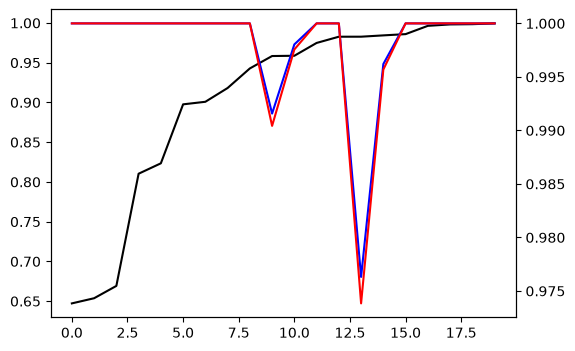

In [144]:
fig, ax1 = plt.subplots(figsize=(6, 4))

ax1.plot(defect_results[:, 0], color='k')
ax2 = ax1.twinx()

ax2.plot(defect_results[:, 1], color='b')
ax2.plot(defect_results[:, 2], color='r')

In [145]:
np.max(np.abs(np.array([l[4] for l in purification_rho_sweep_results])))

np.float64(6.141257458360803e-30)

So this method works, and appears to work well. But why?

#### Non-trivial

In [146]:
purification_rho_sweep_results = [l[1] for l in sweep_results[1]]

In [147]:
purification_rho_sweep_results[0][0]

array([0.04599438, 0.0407341 , 0.02946394, 0.02836969, 0.02572721,
       0.02355541])

In [148]:
purification_rho_sweep_results[-1][0]

array([0.08870657, 0.02412745, 0.01248052])

In [162]:
schmidt_vals = [
    [x for x in l[0] if x > 0.005]
    for l in purification_rho_sweep_results
]

In [163]:
num_schmidt_vals = [len(l) for l in schmidt_vals]

In [164]:
Counter(num_schmidt_vals)

Counter({2: 6, 3: 6, 4: 4, 6: 3, 1: 1})

In [165]:
purification_rho_sweep_results[0][0]

array([0.04599438, 0.0407341 , 0.02946394, 0.02836969, 0.02572721,
       0.02355541])

In [166]:
schmidt_vals

[[np.float64(0.04599438417964919),
  np.float64(0.04073410052349174),
  np.float64(0.029463936620856203),
  np.float64(0.028369694907306637),
  np.float64(0.025727206857576193),
  np.float64(0.023555414388877635)],
 [np.float64(0.034000329952020424),
  np.float64(0.01926090560042185),
  np.float64(0.018591394783919975),
  np.float64(0.006649746664804874)],
 [np.float64(0.05752172552694261), np.float64(0.028364437827552654)],
 [np.float64(0.05823856617748607),
  np.float64(0.029173347862641374),
  np.float64(0.024395646415397803)],
 [np.float64(0.0704896598669885), np.float64(0.06628701123355664)],
 [np.float64(0.020082015427194438),
  np.float64(0.017297973277270135),
  np.float64(0.010201346191406483)],
 [np.float64(0.03838983758259502),
  np.float64(0.03824588157590958),
  np.float64(0.028753922911242732),
  np.float64(0.028474807378642317),
  np.float64(0.024190083894722235),
  np.float64(0.023625294901847636)],
 [np.float64(0.08356372980671312), np.float64(0.01871740647675251)],
 [

In [167]:
schmidt_val_ratios = [
    get_schmidt_vals_ratio(l)
    for l in schmidt_vals
]

In [168]:
pd.Series(triv_schmidt_val_ratios).describe()

count    20.000000
mean      0.295764
std       0.248394
min       0.000000
25%       0.111002
50%       0.245900
75%       0.475620
max       0.722733
dtype: float64

In this case, the results are different!

In [169]:
left_defect_op_invariants = np.array([
    l[1] for l in purification_rho_sweep_results
])

right_defect_op_invariants = np.array([
    l[2] for l in purification_rho_sweep_results
])

In [170]:
(
    np.max(np.abs(np.imag(left_defect_op_invariants))),
    np.max(np.abs(np.imag(right_defect_op_invariants)))
)

(np.float64(1.734723475976807e-16), np.float64(1.6653345369377348e-16))

In [171]:
np.round(left_defect_op_invariants, 3)

array([ 1.   +0.j,  1.   -0.j,  1.   +0.j,  1.   +0.j, -1.   +0.j,
        1.   +0.j,  1.   -0.j,  1.   +0.j,  1.   +0.j,  1.   -0.j,
        0.971+0.j,  1.   -0.j,  1.   +0.j, -0.503-0.j,  1.   -0.j,
        0.751+0.j, -1.   -0.j,  1.   +0.j,  1.   -0.j,  1.   +0.j])

In [172]:
np.round(right_defect_op_invariants, 3)

array([ 1.   +0.j,  1.   +0.j,  1.   +0.j,  1.   -0.j, -1.   -0.j,
        1.   +0.j,  1.   -0.j,  1.   -0.j,  1.   +0.j,  1.   +0.j,
        0.972-0.j,  1.   +0.j,  1.   +0.j, -0.506+0.j,  1.   -0.j,
        0.748+0.j, -1.   +0.j,  1.   +0.j,  1.   -0.j,  1.   +0.j])

In [173]:
overlaps = np.array([
    l[3] for l in purification_rho_sweep_results
])

In [174]:
np.max(np.abs(np.imag(overlaps)))

np.float64(0.0)

In [175]:
overlaps = np.real(overlaps[:, -1])

In [176]:
pd.Series(overlaps).describe()

count    20.000000
mean      0.189813
std       0.083948
min       0.019947
25%       0.121980
50%       0.213104
75%       0.248573
max       0.353155
dtype: float64

In [180]:
defect_results = np.stack(
    (
        overlaps,
        np.real(left_defect_op_invariants),
        np.real(right_defect_op_invariants)
    ),
    axis=-1
)

In [181]:
defect_results = defect_results[defect_results[:, 0].argsort()]

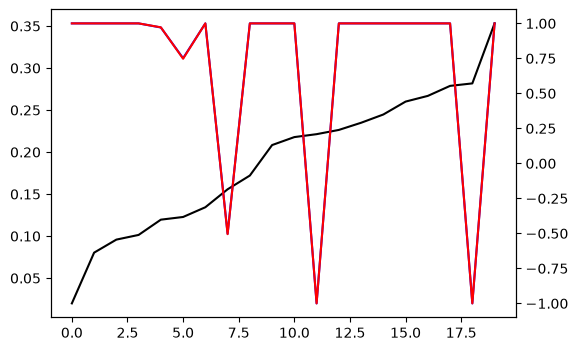

In [182]:
fig, ax1 = plt.subplots(figsize=(6, 4))

ax1.plot(defect_results[:, 0], color='k')
ax2 = ax1.twinx()

ax2.plot(defect_results[:, 1], color='b')
ax2.plot(defect_results[:, 2], color='r')

In [183]:
np.max(np.abs(np.array([l[4] for l in purification_rho_sweep_results])))

np.float64(7.417317107087698e-31)

### Purificaiton and defect operators on cut states

#### Non-trivial

In [190]:
purification_diffs = [l[2] for l in sweep_results[1]]

In [191]:
np.max(np.abs(np.array(purification_diffs)))

np.float64(7.417317107087698e-31)

In [192]:
purification_cut_state_sweep_results = [l[3] for l in sweep_results[1]]

In [193]:
purification_cut_state_sweep_results[0][0]

[np.float64(0.1250000000000018),
 array([0.07177567, 0.06396064, 0.05087751, 0.0409762 , 0.02696398,
        0.02399467]),
 np.complex128(0.9999999997021352+3.614691539144399e-07j),
 np.complex128(0.999999999500248-1.1382109505186921e-06j),
 [np.float64(0.3451128644355559),
  np.float64(0.19301539987470093),
  np.float64(0.20126659758311943),
  np.float64(0.20371788619274833),
  np.float64(0.20524097638323716),
  np.float64(0.20632473389207123),
  np.float64(0.20718478027901086),
  np.float64(0.20793639634051347),
  np.float64(0.20865128942144734),
  np.float64(0.2093665577026204),
  np.float64(0.2101031613638901),
  np.float64(0.2108681193840604),
  np.float64(0.21166171363086556),
  np.float64(0.21247817396663635),
  np.float64(0.2133086920295338),
  np.float64(0.21414207261816087),
  np.float64(0.214966379286244),
  np.float64(0.21576968733102142),
  np.float64(0.21654113314083723),
  np.float64(0.2172714510255116),
  np.float64(0.21795349534794817),
  np.float64(0.21858234019186507

Won't even analyze, as it doesn't work in the simpler case.

### Tensor network factorizations

#### Trivial

In [194]:
factorization_loss_curves = [l[4] for l in sweep_results[0]]

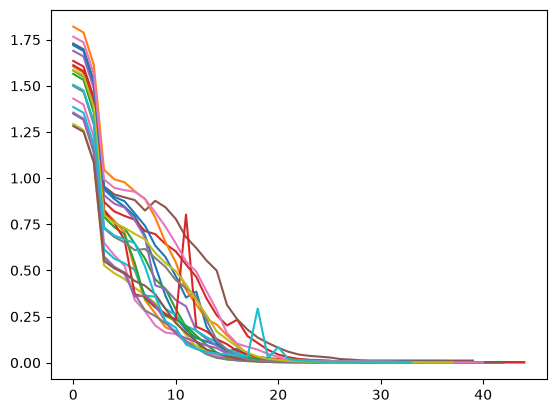

In [195]:
for l in factorization_loss_curves:
    plt.plot(l);

In [196]:
best_loss = [min(l) for l in factorization_loss_curves]

In [198]:
pd.Series(best_loss).describe()

count    20.000000
mean      0.002830
std       0.002443
min       0.000499
25%       0.001377
50%       0.001798
75%       0.004139
max       0.011326
dtype: float64

In [203]:
left_loss = np.array([l[6] for l in sweep_results[0]])
right_loss = np.array([l[7] for l in sweep_results[0]])

In [205]:
(
    np.max(np.abs(np.imag(left_loss))),
    np.max(np.abs(np.imag(right_loss)))
)

(np.float32(0.0), np.float32(0.0))

In [206]:
left_loss = np.real(left_loss)
right_loss = np.real(right_loss)

In [209]:
np.max(left_loss), np.max(right_loss)

(np.float32(1.1258458e-11), np.float32(3.246032e-11))

#### Nontrivial

In [210]:
factorization_loss_curves = [l[4] for l in sweep_results[1]]

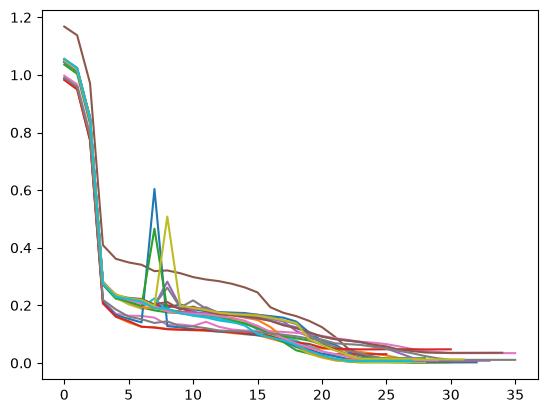

In [211]:
for l in factorization_loss_curves:
    plt.plot(l);

In [212]:
best_loss = [min(l) for l in factorization_loss_curves]

In [213]:
pd.Series(best_loss).describe()

count    20.000000
mean      0.013786
std       0.012575
min       0.001371
25%       0.007165
50%       0.009391
75%       0.013341
max       0.047063
dtype: float64

In [214]:
left_loss = np.array([l[6] for l in sweep_results[1]])
right_loss = np.array([l[7] for l in sweep_results[1]])

In [215]:
(
    np.max(np.abs(np.imag(left_loss))),
    np.max(np.abs(np.imag(right_loss)))
)

(np.float32(0.0), np.float32(0.0))

In [216]:
left_loss = np.real(left_loss)
right_loss = np.real(right_loss)

In [217]:
np.max(left_loss), np.max(right_loss)

(np.float32(3.8853118e-12), np.float32(3.5030498e-12))

### Factorized full effective density matrix

#### Trivial

In [221]:
schmidt_vals = [
    [x for x in l[8] if x > 0.05]
    for l in sweep_results[0]
]

In [222]:
schmidt_vals

[[np.float64(0.8202289534375529),
  np.float64(0.22068283362548022),
  np.float64(0.22004131491972093),
  np.float64(0.0588033556755285)],
 [np.float64(0.8378828598024409)],
 [np.float64(0.6528199780912357)],
 [np.float64(0.5781640639903239),
  np.float64(0.15889836797767495),
  np.float64(0.1587794336819768)],
 [np.float64(0.7940628677460556),
  np.float64(0.22886804609595798),
  np.float64(0.22883087810674918),
  np.float64(0.06592520318899912)],
 [np.float64(0.6895078581378618)],
 [np.float64(0.46864961006252986)],
 [np.float64(0.5689929863071331)],
 [np.float64(0.47851067598438024),
  np.float64(0.09107756223802628),
  np.float64(0.0907829527320157)],
 [np.float64(0.6278646622457713),
  np.float64(0.05849669540343978),
  np.float64(0.05836578985652931)],
 [np.float64(0.7010358322839602),
  np.float64(0.3686451267777533),
  np.float64(0.3683238508318005),
  np.float64(0.19345286708030668)],
 [np.float64(0.5845286354460887),
  np.float64(0.4069622001896736),
  np.float64(0.4069495456

In [223]:
num_schmidt_vals = [len(l) for l in schmidt_vals]

In [224]:
Counter(num_schmidt_vals)

Counter({4: 9, 1: 6, 3: 5})

In [225]:
schmidt_val_ratios = [
    get_schmidt_vals_ratio(l)
    for l in schmidt_vals
]

In [226]:
pd.Series(schmidt_val_ratios).describe()

count    20.000000
mean      0.277027
std       0.262922
min       0.000000
25%       0.000000
50%       0.229693
75%       0.475578
max       0.727395
dtype: float64

In [230]:
left_invariants = [l[9] for l in sweep_results[0]]
right_invariants = [l[10] for l in sweep_results[0]]

In [231]:
left_invariants

[np.complex128(0.999999999999946-2.3677386995490934e-09j),
 np.complex128(0.9999999999999623-7.693359560523305e-10j),
 np.complex128(0.9999999999986042-2.0071281886524517e-08j),
 np.complex128(0.9999999999999903-6.461486484754531e-10j),
 np.complex128(1.0000000000000093-5.09889214184156e-11j),
 np.complex128(0.999999999997772+1.628351526949956e-07j),
 np.complex128(0.9999999999998305-1.2620373635030546e-09j),
 np.complex128(0.9999999999999984-4.3194420262793187e-10j),
 np.complex128(0.9999999999999976-3.8478376734873976e-10j),
 np.complex128(0.99999999999991+3.1825275748076365e-10j),
 np.complex128(0.999991410466619+1.1245922993646795e-05j),
 np.complex128(0.994547766789716-0.0012947859509509496j),
 np.complex128(0.9999999999999153+4.007936760253017e-10j),
 np.complex128(0.9999999999999867+4.693505584185687e-10j),
 np.complex128(0.9999999999999534-3.2743358996389915e-09j),
 np.complex128(0.9998542205356591+3.9009213483987004e-05j),
 np.complex128(0.9999999998996756-1.037585051766321e-0

In [232]:
right_invariants

[np.complex128(0.9999999999998119+1.0786253959449432e-08j),
 np.complex128(1.0000000000000109+3.8690134429586465e-10j),
 np.complex128(0.999999999999737-3.6936909919571548e-09j),
 np.complex128(1.0000000000000013+8.862078640370363e-10j),
 np.complex128(0.9999999999996649+2.6657592966383703e-08j),
 np.complex128(0.9999999999999842-2.126876452734905e-11j),
 np.complex128(0.9999999999999807+4.5294053577227267e-10j),
 np.complex128(0.9999999999996712-6.979028716047608e-09j),
 np.complex128(0.9999999999999828+7.101347287985504e-11j),
 np.complex128(0.9999999999995699-4.269231079767621e-09j),
 np.complex128(0.9999870073622991-1.5019932901524924e-05j),
 np.complex128(0.9937361429612188+0.001539927788807488j),
 np.complex128(0.9999999999999615-7.771545074142239e-10j),
 np.complex128(0.9999999999999738-3.429703028523523e-09j),
 np.complex128(0.9999999999997993+2.225846881809268e-09j),
 np.complex128(0.9998193663040598-6.396630174113072e-05j),
 np.complex128(0.9999999998242428+1.0664645916716453

In [238]:
overlaps = np.array([l[11][-1] for l in sweep_results[0]])

In [239]:
np.max(np.abs(np.imag(overlaps)))

np.float64(0.0)

In [241]:
overlaps = np.real(overlaps)

In [242]:
pd.Series(overlaps).describe()

count    20.000000
mean      0.864144
std       0.177742
min       0.250000
25%       0.850394
50%       0.937572
75%       0.967698
max       0.988875
dtype: float64

In [246]:
defect_results = np.stack(
    (
        overlaps,
        np.real(left_invariants),
        np.real(right_invariants)
    ),
    axis=-1
)

In [247]:
defect_results = defect_results[defect_results[:, 0].argsort()]

(-1.05, 1.05)

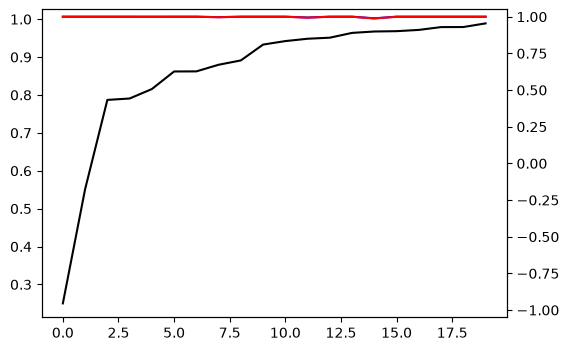

In [249]:
fig, ax1 = plt.subplots(figsize=(6, 4))

ax1.plot(defect_results[:, 0], color='k')
ax2 = ax1.twinx()

ax2.plot(defect_results[:, 1], color='b')
ax2.plot(defect_results[:, 2], color='r')

ax2.set_ylim(-1.05, 1.05)

#### Nontrivial

In [252]:
schmidt_vals = [
    [x for x in l[8] if x > 0.005]
    for l in sweep_results[1]
]

In [253]:
schmidt_vals

[[np.float64(0.09999361547622068),
  np.float64(0.08134757131967987),
  np.float64(0.05539296319448548),
  np.float64(0.0052416107330810705)],
 [np.float64(0.04026530050242864),
  np.float64(0.021732138288459515),
  np.float64(0.01223677476288298),
  np.float64(0.0057089326606037955)],
 [np.float64(0.09229093344079395),
  np.float64(0.009338932399470156),
  np.float64(0.005490106817838717)],
 [np.float64(0.042292447900905555),
  np.float64(0.01865375312492869),
  np.float64(0.012105760100880967)],
 [np.float64(0.014117907912976456),
  np.float64(0.008656786877799258),
  np.float64(0.005620974614256694)],
 [np.float64(0.012141120016462054),
  np.float64(0.011587239974192991),
  np.float64(0.007506158923430117),
  np.float64(0.006323689599985456),
  np.float64(0.005954898558518516)],
 [np.float64(0.010491267285405219),
  np.float64(0.008275711774736585),
  np.float64(0.006074695200241796),
  np.float64(0.0054903600421331526),
  np.float64(0.005221756864487847)],
 [np.float64(0.0113470860

In [254]:
num_schmidt_vals = [len(l) for l in schmidt_vals]

In [255]:
Counter(num_schmidt_vals)

Counter({3: 7, 4: 6, 5: 3, 2: 3, 7: 1})

In [256]:
schmidt_val_ratios = [
    get_schmidt_vals_ratio(l)
    for l in schmidt_vals
]

In [257]:
pd.Series(schmidt_val_ratios).describe()

count    20.000000
mean      0.596463
std       0.206077
min       0.101190
25%       0.525553
50%       0.590902
75%       0.677403
max       0.988021
dtype: float64

A bit more entangled...

In [259]:
left_invariants = [l[9] for l in sweep_results[1]]
right_invariants = [l[10] for l in sweep_results[1]]

In [260]:
left_invariants

[np.complex128(0.9999999999999987+0j),
 np.complex128(0.999999999999819+2.7755575615628914e-17j),
 np.complex128(0.9999999999999396+0j),
 np.complex128(0.9999999999999779+2.7755575615628914e-17j),
 np.complex128(0.9999999999995628-6.938893903907228e-18j),
 np.complex128(0.9999999999991152-1.734723475976807e-17j),
 np.complex128(0.9999999999992125+1.3877787807814457e-17j),
 np.complex128(0.9999999999997211-2.7755575615628914e-17j),
 np.complex128(0.9999999999999792+4.48102144279261e-09j),
 np.complex128(0.9999999997492155+6.938893903907228e-18j),
 np.complex128(0.37368766454758956-1.3877787807814457e-16j),
 np.complex128(0.9999999999998948+2.7755575615628914e-17j),
 np.complex128(0.9999999999999594-1.3877787807814457e-17j),
 np.complex128(0.9999999999999892+5.551115123125783e-17j),
 np.complex128(0.9999999999998812-1.3877787807814457e-17j),
 np.complex128(0.9999999999996908+3.576569183871836e-08j),
 np.complex128(0.9999999999995479+0j),
 np.complex128(-0.9999999999993027-1.3877787807814

In [261]:
right_invariants

[np.complex128(1.0000000000000013+0j),
 np.complex128(0.999999999999579+8.911755472462701e-09j),
 np.complex128(1.0000000000000036+0j),
 np.complex128(0.9999999999999325-2.7755575615628914e-17j),
 np.complex128(0.9999999999998488+0j),
 np.complex128(0.9999999999987771+3.469446951953614e-17j),
 np.complex128(0.9999999999986532+5.551115123125783e-17j),
 np.complex128(0.9999999999950382+0j),
 np.complex128(0.9999999999999447-5.551115123125783e-17j),
 np.complex128(0.9999999995021711+3.1794702542997655e-07j),
 np.complex128(0.37954398187496613+6.938893903907228e-17j),
 np.complex128(0.9999999999969253+0j),
 np.complex128(0.9999999999999342+0j),
 np.complex128(0.999999999999959-2.1806313699190838e-10j),
 np.complex128(0.9999999999996904+5.551115123125783e-17j),
 np.complex128(0.9999999999994788-2.5141366336023374e-08j),
 np.complex128(0.9999999999984658+6.938893903907228e-18j),
 np.complex128(-0.9999999999832494+5.551115123125783e-17j),
 np.complex128(0.999999999998817+0j),
 np.complex128(0

In [263]:
overlaps = np.array([l[11][-1] for l in sweep_results[1]])

In [264]:
np.max(np.abs(np.imag(overlaps)))

np.float64(0.0)

In [265]:
overlaps = np.real(overlaps)

In [266]:
pd.Series(overlaps).describe()

count    20.000000
mean      0.111314
std       0.098319
min       0.028290
25%       0.044665
50%       0.076124
75%       0.137430
max       0.399655
dtype: float64

In [267]:
defect_results = np.stack(
    (
        overlaps,
        np.real(left_invariants),
        np.real(right_invariants)
    ),
    axis=-1
)

In [268]:
defect_results = defect_results[defect_results[:, 0].argsort()]

(-1.05, 1.05)

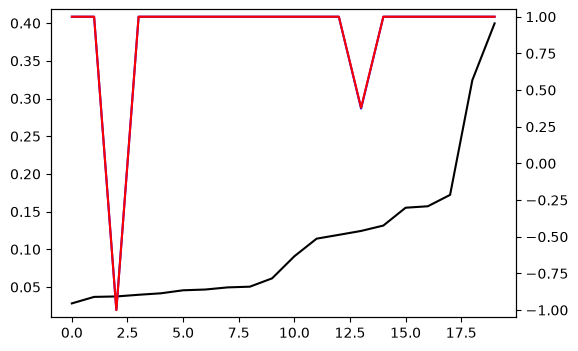

In [269]:
fig, ax1 = plt.subplots(figsize=(6, 4))

ax1.plot(defect_results[:, 0], color='k')
ax2 = ax1.twinx()

ax2.plot(defect_results[:, 1], color='b')
ax2.plot(defect_results[:, 2], color='r')

ax2.set_ylim(-1.05, 1.05)

### Factorized cut states

#### Trivial

In [270]:
factorized_cut_state_sweep_results = [l[12] for l in sweep_results[0]]

In [271]:
factorized_cut_state_sweep_results[0][0]

[np.float32(1.9115489),
 np.float32(2.0338612),
 array([9.26524312e-01, 2.47685909e-01, 2.47685007e-01, 6.62140957e-02,
        1.13237665e-03, 1.13086217e-03, 3.14054433e-04, 3.06700907e-04,
        2.64873601e-04, 2.41017630e-04, 6.73275649e-05, 6.55357105e-05,
        4.52978610e-06, 1.24495828e-06, 4.06744837e-07, 1.36787667e-07]),
 np.complex128(1.0000002384185789-2.7755575615628914e-17j),
 np.complex128(1.0000000447034838-2.7706846539299335e-08j),
 np.float64(0.9999195946512053)]

In [273]:
all_left_indices = [
    l1[4]
    for l in factorized_cut_state_sweep_results
    for l1 in l
]

In [274]:
all_left_indices

[np.complex128(1.0000000447034838-2.7706846539299335e-08j),
 np.complex128(1.000000074505806-6.519258133330652e-09j),
 np.complex128(0.9999999403953559-5.471520125865936e-09j),
 np.complex128(0.9999998509883877+6.984913758500966e-10j),
 np.complex128(0.9999999403953557-2.6077030201854257e-08j),
 np.complex128(0.9999998062849044-5.0640664994716644e-09j),
 np.complex128(0.9999998956918721+5.355104790161214e-09j),
 np.complex128(0.9999998807907109+8.381903060517004e-09j),
 np.complex128(0.9999999403953547+4.656612873077393e-10j),
 np.complex128(1.0000000298023208-1.862645143679842e-08j),
 np.complex128(0.9999972881942512+1.6990146055606559e-06j),
 np.complex128(0.9022015420838576+0.0270465064224584j),
 np.complex128(0.9999999478458497-1.042052716337949e-08j),
 np.complex128(1.0000000596046448-5.587935336670569e-09j),
 np.complex128(0.9999998211860657-2.991873768176667e-08j),
 np.complex128(0.9999834406091122-8.004885023824015e-06j),
 np.complex128(1.0000001040327295+5.226571175853678e-09j

In [275]:
all_right_indices = [
    l1[5]
    for l in factorized_cut_state_sweep_results
    for l1 in l
]

In [276]:
all_right_indices

[np.float64(0.9999195946512053),
 np.float64(0.9999065370392503),
 np.float64(0.9998837346303051),
 np.float64(0.9996757300859063),
 np.float64(0.9999048239895376),
 np.float64(0.999491977328418),
 np.float64(0.9999012295161577),
 np.float64(0.9999352516229341),
 np.float64(0.9999290501343576),
 np.float64(0.9998285974926882),
 np.float64(0.9999734934416629),
 np.float64(0.9951390304808002),
 np.float64(0.9998335050456959),
 np.float64(0.9999274894823622),
 np.float64(0.9997707338963313),
 np.float64(0.9999594923610118),
 np.float64(0.9999771144216046),
 np.float64(0.9892360085766263),
 np.float64(0.9987063425956249),
 np.float64(0.9994914977068288)]

Good overlaps.

#### Nontrivial

In [277]:
factorized_cut_state_sweep_results = [l[12] for l in sweep_results[1]]

In [278]:
factorized_cut_state_sweep_results[0][0]

[np.float32(1.1264889),
 np.float32(0.8873818),
 array([5.49922966e-02, 4.52878778e-02, 3.14501349e-02, 9.88040585e-03,
        4.93492075e-03, 4.62631051e-03, 3.75187488e-03, 2.10422318e-03,
        1.27481048e-03, 1.22100009e-03, 6.55788282e-04, 4.56258941e-04,
        7.77041542e-05, 4.14142625e-05, 3.04655418e-05, 1.81227827e-06]),
 np.complex128(1.0000000298023226-2.4091839634365897e-14j),
 np.complex128(1.0000000745058057-2.0023230518084745e-08j),
 np.float64(0.1542139484903972)]

In [279]:
all_left_indices = [
    l1[4]
    for l in factorized_cut_state_sweep_results
    for l1 in l
]

In [280]:
all_left_indices

[np.complex128(1.0000000745058057-2.0023230518084745e-08j),
 np.complex128(1.0000000596046448+1.4615222365677027e-08j),
 np.complex128(1.0000000521540637-1.3038234547568806e-08j),
 np.complex128(1.0000000894069674+4.799436403857271e-10j),
 np.complex128(0.9999997802078727-1.1175860070711252e-08j),
 np.complex128(1.0000000894069665-3.883763532996909e-09j),
 np.complex128(0.9999997913837435-1.2107180022424835e-08j),
 np.complex128(1.0000000298023224+9.832936742615317e-09j),
 np.complex128(-1.0000000919676988-5.1530774397567924e-06j),
 np.complex128(-0.9943230347718264-0.0026326153282170695j),
 np.complex128(1.0000000893123775-5.533305338367711e-07j),
 np.complex128(-1.0000001937150949-1.8626981901359585e-09j),
 np.complex128(0.999993002034989-0.0002548099875186449j),
 np.complex128(1.0000001788029957-9.558409397314449e-09j),
 np.complex128(0.9999999552963791+5.513251169486644e-08j),
 np.complex128(0.9999999850986312-2.34299033119445e-07j),
 np.complex128(0.07041851792733322-0.02953722714

In [281]:
all_right_indices = [
    l1[5]
    for l in factorized_cut_state_sweep_results
    for l1 in l
]

In [282]:
all_right_indices

[np.float64(0.1542139484903972),
 np.float64(0.7926913140273534),
 np.float64(0.45234365168148954),
 np.float64(0.514590298031277),
 np.float64(0.15400857339720636),
 np.float64(0.7941967708766546),
 np.float64(0.44855206785943225),
 np.float64(0.5123614163807818),
 np.float64(0.2047267715204616),
 np.float64(0.21434590465230535),
 np.float64(0.2847079178324088),
 np.float64(0.23548459859728416),
 np.float64(0.45952392301997635),
 np.float64(0.6195217924279847),
 np.float64(0.9293241515298656),
 np.float64(0.5949641233822892),
 np.float64(0.27967001884437903),
 np.float64(0.378035800508117),
 np.float64(0.47974017502853467),
 np.float64(0.37805924133286123),
 np.float64(0.796079421084521),
 np.float64(0.7806869579390884),
 np.float64(0.5953799537646782),
 np.float64(0.5819344952245192),
 np.float64(0.5377157526420642),
 np.float64(0.5542318190742835),
 np.float64(0.7728364251718045),
 np.float64(0.7814612761919677),
 np.float64(0.4275306296218549),
 np.float64(0.8378605626403475),
 np.

Good overlaps.

# Conclusions
Not good!

# Old code

## Apply random symmetries test

In [13]:
psi = groundstates[0]

In [15]:
basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)

In [16]:
print(basis)

reference states: 
array index   /   Fock state   /   integer repr. 
     0.  |1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1>  65535 
     1.  |1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0>  65534 
     2.  |1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1>  65533 
     3.  |1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0>  65532 
     4.  |1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1>  65531 
     5.  |1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0>  65530 
     6.  |1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1>  65529 
     7.  |1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0>  65528 
     8.  |1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1>  65527 
     9.  |1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0>  65526 
    10.  |1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1>  65525 
    11.  |1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0>  65524 
    12.  |1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1>  65523 
    13.  |1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0>  65522 
    14.  |1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1>  65521 
    15.  |1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0>  65520 
    16.  |1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1>  65519 
    17.  |1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0>  65518 
    18.  |1 1

In [14]:
psi

array([[ 3.90582915e-03+5.73388357e-05j],
       [-5.73388357e-05+3.90582915e-03j],
       [-5.73388357e-05+3.90582915e-03j],
       ...,
       [ 5.73388357e-05-3.90582915e-03j],
       [ 5.73388357e-05-3.90582915e-03j],
       [ 3.90582915e-03+5.73388357e-05j]], shape=(65536, 1))

In [18]:
np.arange(16).reshape((2,)*4)

array([[[[ 0,  1],
         [ 2,  3]],

        [[ 4,  5],
         [ 6,  7]]],


       [[[ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15]]]])

In [22]:
qu_psi = qtn.Tensor(
    psi[::-1].reshape((2,)*num_sites),
    inds=[f'k{i}' for i in range(num_sites)]
)

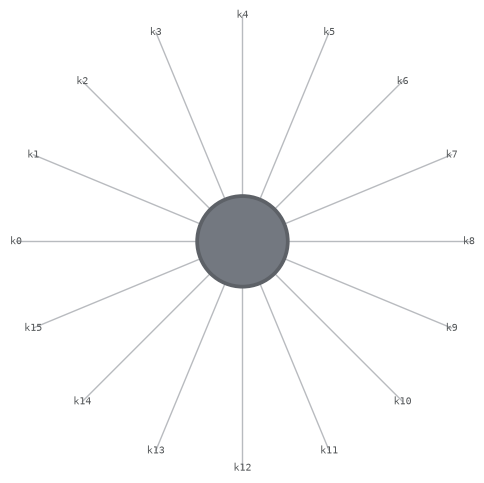

In [23]:
qu_psi.draw()

In [24]:
qu_psi

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2), inds=('k0', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6', 'k7', 'k8', 'k9', 'k10', 'k11', 'k12', 'k13', 'k14', 'k15'), tags=oset([]))

In [50]:
u = qu.gen.rand.rand_uni(4)

In [51]:
np.round(u, 3)

[[ 0.21 -0.234j  0.652+0.471j -0.069+0.35j   0.352-0.063j]
 [ 0.135-0.189j  0.028+0.158j  0.161-0.832j  0.336-0.297j]
 [-0.104-0.254j -0.546-0.004j -0.043+0.381j  0.424-0.548j]
 [-0.657-0.583j -0.056+0.163j  0.049-0.071j  0.048+0.434j]]

In [52]:
np.round(u @ u.T.conj(), 3)

[[ 1.+0.j -0.-0.j -0.-0.j -0.+0.j]
 [-0.+0.j  1.+0.j  0.-0.j  0.-0.j]
 [-0.+0.j  0.+0.j  1.+0.j  0.-0.j]
 [-0.-0.j  0.+0.j  0.+0.j  1.+0.j]]

In [28]:
type(u)

quimb.core.qarray

In [29]:
qu_u = qtn.Tensor(
    qu.gen.rand.rand_uni(4).reshape((2,)*4),
    inds=['k1', 'k2', 'b1', 'b2']
)

In [30]:
out_qu_psi = (
    qu_psi.reindex({'k1': 'b1', 'k2': 'b2'})
    & qu_u
)

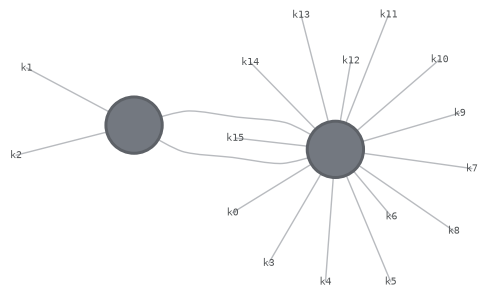

In [32]:
out_qu_psi.draw()

In [33]:
out_qu_psi.contract(inplace=True)

TensorNetwork(tensors=1, indices=16)

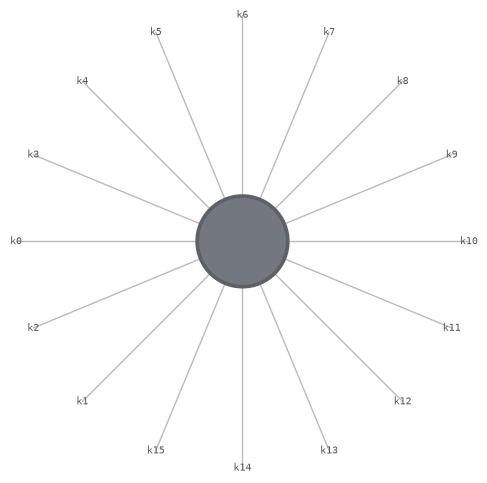

In [34]:
out_qu_psi.draw()

In [37]:
X = out_qu_psi.tensors[0].data.reshape((-1))[::-1]

In [38]:
X.shape

(65536,)

In [39]:
X

array([-0.00220717+0.00142551j, -0.00310542-0.00063017j,
        0.00343488-0.0033824j , ...,  0.00310542+0.00063017j,
       -0.00343488+0.0033824j , -0.00174788+0.00421859j], shape=(65536,))

In [54]:
# Warning, likely making assupmtions about shape of psi, number of sites being even here etc.
def apply_haar_random_fdlu_to_quspin_state(psi):
    qu_psi = qtn.Tensor(
        psi[::-1].reshape((2,)*num_sites),
        inds=[f'k{i}' for i in range(num_sites)]
    )

    for delta in [0,1]:
        for i in range(num_sites//2):
            site_1 = ((2*i)+delta)%num_sites
            site_2 = ((2*i)+1+delta)%num_sites
    
            qu_u = qtn.Tensor(
                qu.gen.rand.rand_uni(4).reshape((2,)*4),
                inds=[f'k{site_1}', f'k{site_2}', f'b{site_1}', f'b{site_2}']
            )
    
            qu_psi = (
                qu_psi.reindex(
                    {f'k{site_1}':  f'b{site_1}', f'k{site_2}': f'b{site_2}'}
                )
                & qu_u
            )
            qu_psi.contract(inplace=True)

    out_psi = qu_psi.tensors[0].data.reshape((-1))[::-1]

    return out_psi

In [64]:
test_psis = [
    apply_haar_random_fdlu_to_quspin_state(psi) 
    for _ in range(100)
]

In [67]:
diffs = list()

for psi_rand in test_psis:
    overlap = np.dot(psi.conj()[:, 0], psi_rand)
    diffs.append(overlap)

diffs = np.array(diffs)

In [69]:
np.round(diffs, 3)

array([ 0.001-0.003j, -0.   -0.002j, -0.   -0.001j, -0.004+0.005j,
        0.001-0.003j, -0.   +0.j   ,  0.01 +0.002j, -0.   -0.j   ,
        0.003-0.001j,  0.001+0.001j,  0.001+0.j   ,  0.   +0.j   ,
       -0.001-0.j   ,  0.002-0.001j, -0.   -0.001j, -0.001-0.001j,
       -0.   -0.j   ,  0.   -0.j   ,  0.001-0.j   , -0.   -0.j   ,
        0.001-0.j   ,  0.004+0.004j, -0.001-0.003j, -0.001-0.004j,
        0.003-0.001j, -0.007+0.013j, -0.   -0.001j, -0.   -0.001j,
        0.   -0.j   , -0.001-0.001j,  0.001-0.002j, -0.001-0.j   ,
       -0.   -0.j   ,  0.   +0.002j,  0.   +0.001j, -0.   -0.002j,
        0.002-0.001j,  0.001+0.001j,  0.002+0.005j,  0.   -0.001j,
       -0.003-0.j   , -0.001+0.004j, -0.002-0.002j, -0.   -0.j   ,
       -0.   +0.j   ,  0.003+0.006j, -0.   +0.j   , -0.002-0.001j,
       -0.001+0.002j, -0.   +0.004j, -0.004+0.004j,  0.002+0.j   ,
        0.002-0.002j, -0.   +0.j   , -0.002+0.002j,  0.   -0.j   ,
       -0.   +0.001j, -0.002+0.001j, -0.001-0.001j,  0.001-0.0

In [70]:
from itertools import combinations

In [71]:
diffs = list()

for psi_1, psi_2 in combinations(test_psis, 2):
    overlap = np.dot(psi_1.conj(), psi_2)
    diffs.append(overlap)

diffs = np.array(diffs)

In [72]:
np.abs(diffs)

array([0.00134098, 0.00037768, 0.00015354, ..., 0.00254437, 0.00191283,
       0.00027508], shape=(4950,))

## Generate and test random unitaries respecting $XK$ symmetry

In [87]:
o = ortho_group.rvs(4)

In [88]:
o

array([[ 0.38102352, -0.79409578,  0.27917744, -0.38248259],
       [ 0.77824464,  0.51678111, -0.07115791, -0.34958419],
       [-0.44998244,  0.28812547,  0.50418709, -0.67845036],
       [ 0.21603739,  0.13904278,  0.81412031,  0.52077161]])

In [89]:
np_H = np.pow(2, -1/2)*np.array([
    [1,1],
    [1,-1]
])

In [90]:
np_W = np.kron(np_H, np_H) @ np.diag([1, 1j, 1j, 1])

In [91]:
np_W

array([[ 0.5+0.j ,  0. +0.5j,  0. +0.5j,  0.5+0.j ],
       [ 0.5+0.j ,  0. -0.5j,  0. +0.5j, -0.5+0.j ],
       [ 0.5+0.j ,  0. +0.5j,  0. -0.5j, -0.5+0.j ],
       [ 0.5+0.j ,  0. -0.5j,  0. -0.5j,  0.5+0.j ]])

In [92]:
u = np_W @ o @ (np_W.conj().T)

In [93]:
u

array([[ 0.49332143-0.28450428j,  0.02172362-0.0980135j ,
         0.20766232+0.77616188j, -0.12564645-0.0653819j ],
       [-0.09789468-0.02225296j,  0.46806024-0.32438915j,
         0.06605992-0.12529131j, -0.27123936-0.75629367j],
       [-0.27123936+0.75629367j,  0.06605992+0.12529131j,
         0.46806024+0.32438915j, -0.09789468+0.02225296j],
       [-0.12564645+0.0653819j ,  0.20766232-0.77616188j,
         0.02172362+0.0980135j ,  0.49332143+0.28450428j]])

In [94]:
qu_u = qtn.Tensor(
    u.reshape((2,)*4),
    inds=['k1', 'k2', 'b1', 'b2']
)

In [95]:
qu_XX_2_site = qtn.Tensor(
    np_XX.reshape((2,)*4),
    inds=['k1', 'k2', 'b1', 'b2']
)   

In [96]:
t1 = (
    qu_XX_2_site.reindex({'b1': 'i1', 'b2': 'i2'})
    & qu_u.reindex({'k1': 'i1', 'k2': 'i2'})
)
t1.contract(inplace=True)

t2 = (
    qu_u.conj().reindex({'b1': 'i1', 'b2': 'i2'})
    & qu_XX_2_site.reindex({'k1': 'i1', 'k2': 'i2'})
)
t2.contract(inplace=True)

TensorNetwork(tensors=1, indices=4)

In [97]:
np.linalg.norm(t1.tensors[0].data - t2.tensors[0].data)

np.float64(0.0)